# Annotation Analysis

This notebook is intended for analyzing annotations and label distributions.

In [ ]:
# Placeholder for annotation analysis code
print('Annotation analysis notebook created')

# AI-Powered Intelligent Traffic Management System

## Phase 2

# Module 3 – Annotation Analysis & Data Quality Assessment

This notebook analyzes annotation quality, bounding box statistics, and dataset integrity.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = Path(r"C:\AI-Powered-Intelligent-Traffic-Management-System\datasets\DETRAC_Upload")

TRAIN_LABELS = DATASET_PATH / "labels/train"
TRAIN_IMAGES = DATASET_PATH / "images/train"

In [3]:
label_files = list(TRAIN_LABELS.glob("*.txt"))

print("="*60)
print("ANNOTATION FILES")
print("="*60)

print("Total Label Files :", len(label_files))

ANNOTATION FILES
Total Label Files : 82085


In [4]:
bbox_width = []
bbox_height = []
bbox_area = []
aspect_ratio = []

class_count = {}

total_objects = 0
empty_files = 0
invalid_boxes = 0

for label in label_files:

    lines = label.read_text().strip().splitlines()

    if len(lines) == 0:
        empty_files += 1
        continue

    for line in lines:

        values = line.split()

        if len(values) != 5:
            invalid_boxes += 1
            continue

        cls, xc, yc, w, h = map(float, values)

        total_objects += 1

        class_count[int(cls)] = class_count.get(int(cls), 0) + 1

        bbox_width.append(w)
        bbox_height.append(h)
        bbox_area.append(w * h)

        if h > 0:
            aspect_ratio.append(w / h)

In [5]:
print("="*60)
print("ANNOTATION SUMMARY")
print("="*60)

print("Total Objects :", total_objects)
print("Empty Label Files :", empty_files)
print("Invalid Boxes :", invalid_boxes)
print("Classes Found :", len(class_count))

ANNOTATION SUMMARY
Total Objects : 598281
Empty Label Files : 0
Invalid Boxes : 0
Classes Found : 4


In [6]:
print("="*60)
print("BOUNDING BOX STATISTICS")
print("="*60)

print("Average Width :", np.mean(bbox_width))
print("Average Height :", np.mean(bbox_height))
print("Average Area :", np.mean(bbox_area))
print("Average Aspect Ratio :", np.mean(aspect_ratio))

BOUNDING BOX STATISTICS
Average Width : 0.09616102030484004
Average Height : 0.11771592705935842
Average Area : 0.015463606534892756
Average Aspect Ratio : 0.8527363208489649


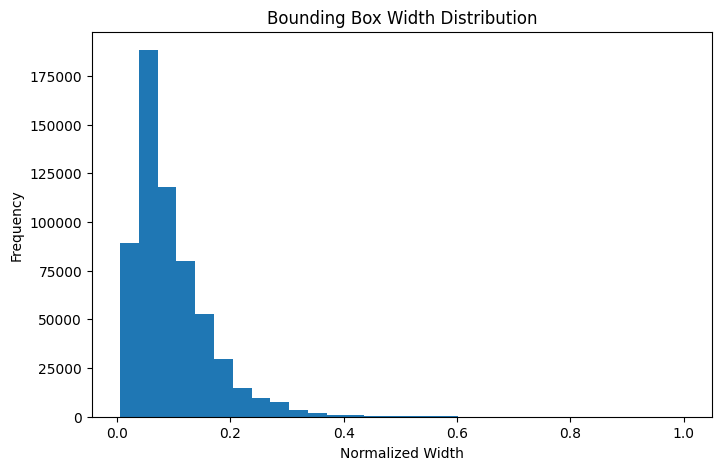

In [7]:
plt.figure(figsize=(8,5))

plt.hist(bbox_width, bins=30)

plt.title("Bounding Box Width Distribution")

plt.xlabel("Normalized Width")

plt.ylabel("Frequency")

plt.show()

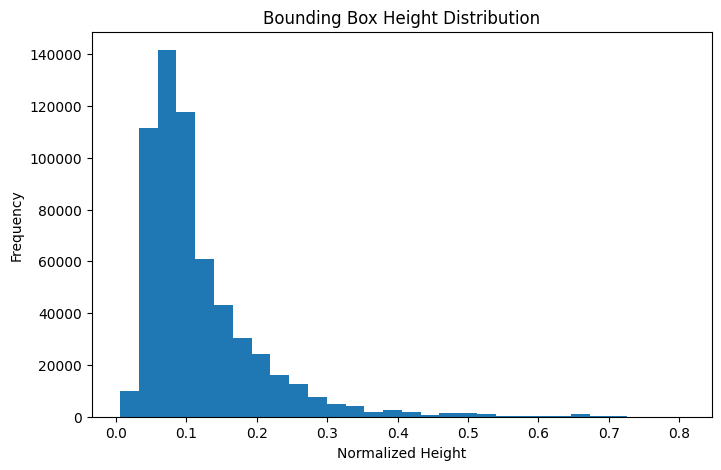

In [8]:
plt.figure(figsize=(8,5))

plt.hist(bbox_height, bins=30)

plt.title("Bounding Box Height Distribution")

plt.xlabel("Normalized Height")

plt.ylabel("Frequency")

plt.show()

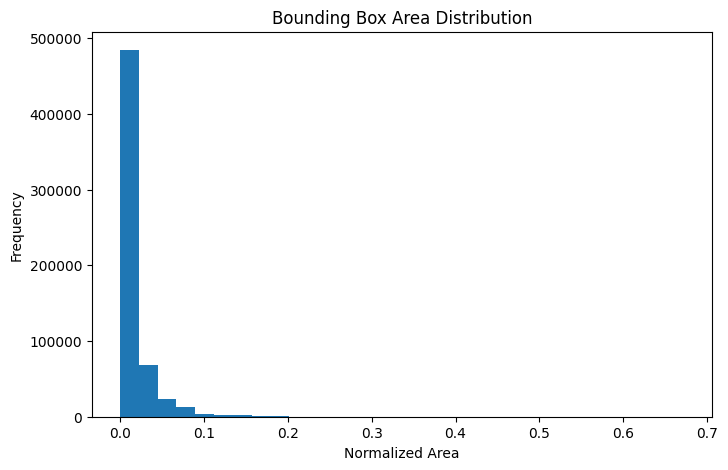

In [9]:
plt.figure(figsize=(8,5))

plt.hist(bbox_area, bins=30)

plt.title("Bounding Box Area Distribution")

plt.xlabel("Normalized Area")

plt.ylabel("Frequency")

plt.show()

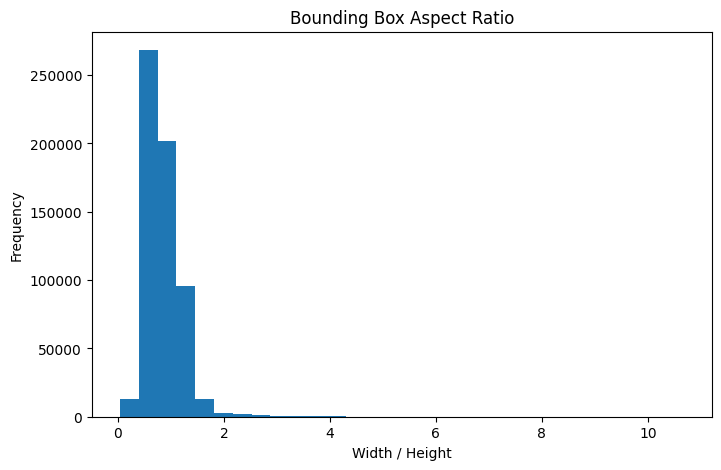

In [10]:
plt.figure(figsize=(8,5))

plt.hist(aspect_ratio, bins=30)

plt.title("Bounding Box Aspect Ratio")

plt.xlabel("Width / Height")

plt.ylabel("Frequency")

plt.show()

In [11]:
class_df = pd.DataFrame({

    "Class": class_count.keys(),
    "Objects": class_count.values()

})

class_df = class_df.sort_values("Class")

class_df

,Class,Objects
2,0,3726
0,1,503853
1,2,57051
3,3,33651


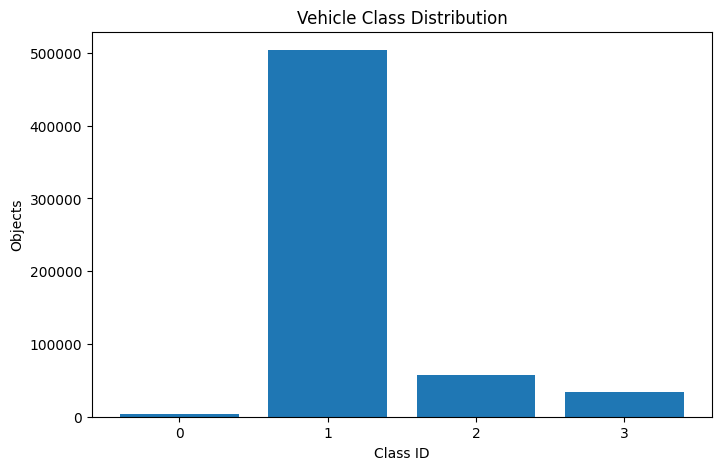

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    class_df["Class"].astype(str),
    class_df["Objects"]
)

plt.title("Vehicle Class Distribution")

plt.xlabel("Class ID")

plt.ylabel("Objects")

plt.show()

In [13]:
object_per_image = []

for label in label_files:

    with open(label) as f:

        count = len(f.readlines())

    object_per_image.append(

        {

            "Image": label.stem,

            "Objects": count

        }

    )

df = pd.DataFrame(object_per_image)

df.sort_values(
    "Objects",
    ascending=False
).head(10)

,Image,Objects
39601,MVI_40204_img00742,27
39604,MVI_40204_img00745,27
39603,MVI_40204_img00744,27
39600,MVI_40204_img00741,27
39605,MVI_40204_img00746,27
39602,MVI_40204_img00743,27
39950,MVI_40204_img01091,26
39671,MVI_40204_img00812,26
39610,MVI_40204_img00751,26
39965,MVI_40204_img01106,26


In [14]:
print("="*60)
print("DATA QUALITY REPORT")
print("="*60)

if invalid_boxes == 0:
    print("✓ No Invalid Bounding Boxes")
else:
    print("✗ Invalid Bounding Boxes Found")

if empty_files == 0:
    print("✓ No Empty Annotation Files")
else:
    print("✗ Empty Annotation Files Found")

print()

print("Dataset Ready for Training ✓")

DATA QUALITY REPORT
✓ No Invalid Bounding Boxes
✓ No Empty Annotation Files

Dataset Ready for Training ✓


In [15]:
print("="*70)
print("MODULE 3 COMPLETED")
print("="*70)

print("✓ Annotation Analysis Completed")
print("✓ Bounding Box Statistics Generated")
print("✓ Dataset Quality Verified")
print("✓ Class Distribution Checked")
print("✓ Images with Maximum Vehicles Identified")
print("✓ Dataset Ready for Deep Learning")

MODULE 3 COMPLETED
✓ Annotation Analysis Completed
✓ Bounding Box Statistics Generated
✓ Dataset Quality Verified
✓ Class Distribution Checked
✓ Images with Maximum Vehicles Identified
✓ Dataset Ready for Deep Learning
